In [1]:
import torch
from pathlib import Path
from subject_builder import SubjectBuilder
from patch_builder import PatchBuilder
import torchio as tio
from torch.utils.data import DataLoader



train_subjects = SubjectBuilder.build_subjects(
    Path("/home/caleb/school/glioseg/data/BraTS-PEDs-v1/Training")
)

val_subjects = train_subjects[-30:]
train_subjects = train_subjects[:-30]

train_builder = PatchBuilder(train_subjects)
train_queue = train_builder.build_patches()

val_builder = PatchBuilder(val_subjects)
val_queue = val_builder.build_patches()

# Data loader from Tio Queues
train_loader =  DataLoader(train_queue, batch_size=1, num_workers=0)
val_loader = DataLoader(val_queue)


"""
FOR SOME FING REASON THE DATASET JUST DOESNT HAVE SEG MASKS FOR THE VALIDATION SET SO ITS USELESS....
train_builder  = PatchBuilder(train_subjects)
train_queue = train_builder.build_patches()
 
val_subjects = SubjectBuilder.build_subjects(
    Path("/home/caleb/school/glioseg/data/BraTS-PEDs-v1/Validation")
)
val_builder = PatchBuilder(val_subjects)
val_queue = val_builder.build_patches()
"""

'\nFOR SOME FING REASON THE DATASET JUST DOESNT HAVE SEG MASKS FOR THE VALIDATION SET SO ITS USELESS....\ntrain_builder  = PatchBuilder(train_subjects)\ntrain_queue = train_builder.build_patches()\n\nval_subjects = SubjectBuilder.build_subjects(\n    Path("/home/caleb/school/glioseg/data/BraTS-PEDs-v1/Validation")\n)\nval_builder = PatchBuilder(val_subjects)\nval_queue = val_builder.build_patches()\n'

In [2]:
from snn_network import SpikingUnet
from snn_network import GroupNormNetwork as GroupSNN
from snn_train import TrainNetwork
from monai.losses import DiceCELoss
from tqdm import trange

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#model = SpikingUnet(in_channels=4, out_chanels=5).to(device)
model = GroupSNN(in_channels=4,out_chanels=5).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
loss_fn = DiceCELoss(to_onehot_y=True, softmax=True,include_background=False)

In [3]:
#import pandas as pd
from tqdm import trange

trainer = TrainNetwork(
    train_queue=train_queue,
    val_queue=val_queue,
    model=model,
    optimizer=optimizer,
    device=device,
    loss_fn=loss_fn,
    spike_len=8,
    batch_size=1,
)

num_epochs = 12
best_val_loss = float("inf")
ckpt_dir = Path("checkpoints")
ckpt_dir.mkdir(parents=True, exist_ok=True)

history = []
epoch_bar = trange(num_epochs, desc="Epochs", leave=True)

for epoch in epoch_bar:
    train_stats = trainer.train()
    val_stats = trainer.validate()

    train_loss = train_stats["loss"]
    val_loss = val_stats["loss"]
    lr = optimizer.param_groups[0]["lr"]
    gap = val_loss - train_loss

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(
            {
                "epoch": epoch + 1,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "best_val_loss": best_val_loss,
            },
            ckpt_dir / "best_group_norm.pt",
        )

    row = {
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "gap_val_minus_train": gap,
        "best_val_loss": best_val_loss,
        "lr": lr,
        "train_samples": train_stats["samples"],
        "val_samples": val_stats["samples"],
        "train_sec": train_stats["seconds"],
        "val_sec": val_stats["seconds"],
        "train_sps": train_stats["samples_per_sec"],
        "val_sps": val_stats["samples_per_sec"],
    }
    history.append(row)

    epoch_bar.set_postfix(
        train=f"{train_loss:.4f}",
        val=f"{val_loss:.4f}",
        best=f"{best_val_loss:.4f}",
        gap=f"{gap:+.4f}",
        lr=f"{lr:.1e}",
    )

#history_df = pd.DataFrame(history)
#display(history_df)

Epochs:   0%|          | 0/12 [00:00<?, ?it/s]

Training:   0%|          | 0/2724 [00:00<?, ?it/s]

Validation:   0%|          | 0/360 [00:00<?, ?it/s]

Epochs:   8%|▊         | 1/12 [11:10<2:03:00, 670.99s/it, best=1.0865, gap=-0.0872, lr=5.0e-04, train=1.1737, val=1.0865]

Training:   0%|          | 0/2724 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/360 [00:00<?, ?it/s]

Epochs:  92%|█████████▏| 11/12 [1:45:28<09:02, 542.48s/it, best=0.9381, gap=+0.0627, lr=5.0e-04, train=0.8972, val=0.9599]

Training:   0%|          | 0/2724 [00:00<?, ?it/s]

Validation:   0%|          | 0/360 [00:00<?, ?it/s]

Epochs: 100%|██████████| 12/12 [1:54:23<00:00, 571.98s/it, best=0.9381, gap=+0.0752, lr=5.0e-04, train=0.8843, val=0.9595]


In [4]:
from monai.metrics import DiceMetric
from monai.transforms import AsDiscrete
from monai.data import decollate_batch
from tqdm.auto import tqdm
from snntorch import spikegen, utils
import torchio as tio
import torch

def evaluate(model, loader, device, spike_len=8, num_classes=5, max_batches=None):
    model.eval()

    dice_mean = DiceMetric(include_background=False, reduction="mean")
    dice_per_class = DiceMetric(include_background=False, reduction="mean_batch")

    post_pred = AsDiscrete(argmax=True, to_onehot=num_classes)
    post_label = AsDiscrete(to_onehot=num_classes)

    batch_dice_metric = DiceMetric(include_background=False, reduction="mean")
    best_sample = None
    best_dice = -1.0
    num_batches = 0
    batch_dice_scores = []

    with torch.no_grad():
        for i, batch in enumerate(tqdm(loader, desc="Eval"), start=1):
            if max_batches is not None and i > max_batches:
                break

            target = batch["seg"][tio.DATA].to(device).long()
            t1c = batch["t1c"][tio.DATA]
            t1n = batch["t1n"][tio.DATA]
            t2w = batch["t2w"][tio.DATA]
            t2f = batch["t2f"][tio.DATA]

            data = torch.cat([t1c, t1n, t2w, t2f], dim=1).to(device, dtype=torch.float32)
            spike_train = spikegen.rate(data, num_steps=spike_len)

            if hasattr(model, "init_mem"):
                model.init_mem()
            else:
                utils.reset(model)

            mem_rec = []
            for step in range(spike_len):
                _, mem_out = model(spike_train[step])
                mem_rec.append(mem_out)

            logits = torch.stack(mem_rec, dim=0).mean(dim=0)
            prediction = logits.argmax(dim=1)

            preds = [post_pred(x) for x in decollate_batch(logits)]
            labels = [post_label(x) for x in decollate_batch(target)]

            dice_mean(y_pred=preds, y=labels)
            dice_per_class(y_pred=preds, y=labels)

            batch_dice_metric(y_pred=preds, y=labels)
            batch_dice = float(batch_dice_metric.aggregate().item())
            batch_dice_metric.reset()

            batch_dice_scores.append(batch_dice)  # <- add

            if batch_dice > best_dice:
                best_dice = batch_dice
                best_sample = {
                    "dice": batch_dice,
                    "mri": data[0, 0].detach().cpu(),
                    "gt": target[0, 0].detach().cpu(),
                    "pred": prediction[0].detach().cpu(),
                }

            num_batches = i

    overall_dice = float(dice_mean.aggregate().item())
    per_class_dice = dice_per_class.aggregate().detach().cpu().tolist()

    dice_mean.reset()
    dice_per_class.reset()

    return {
        "overall_dice": overall_dice,
        "per_class_dice": per_class_dice,
        "num_batches": num_batches,
        "best_sample": best_sample,
        "batch_dice_scores": batch_dice_scores
    }


In [5]:
from torch.utils.data import DataLoader

checkpoint = torch.load(ckpt_dir / "best_group_norm.pt")

model.load_state_dict(checkpoint["model_state"])
optimizer.load_state_dict(checkpoint["optimizer_state"])
start_epoch = checkpoint["epoch"]
best_val_loss = checkpoint["best_val_loss"]

print(f"Loaded checkpoint from epoch {start_epoch}")
print(f"Best val loss: {best_val_loss:.4f}")

checkpoint = torch.load(ckpt_dir / "best_group_norm.pt")
model.load_state_dict(checkpoint["model_state"])
model.eval()


val_loader = DataLoader(val_queue, batch_size=1, num_workers=0)

eval_out = evaluate(model, val_loader, device, spike_len=8)
val_dice = eval_out["overall_dice"]
best_sample = eval_out["best_sample"]
print(val_dice)

Loaded checkpoint from epoch 7
Best val loss: 0.9381


Eval:   0%|          | 0/360 [00:00<?, ?it/s]

0.5624471306800842


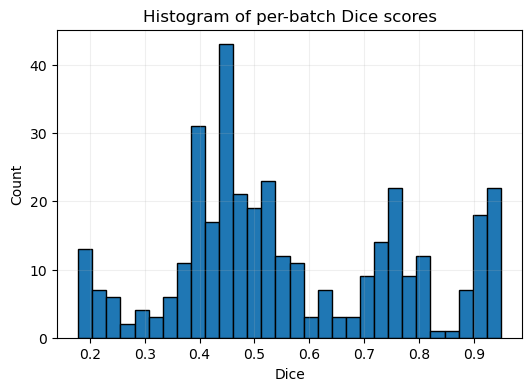

n=360, mean=0.5624, min=0.1787, max=0.9493


In [6]:
import matplotlib.pyplot as plt

scores = eval_out["batch_dice_scores"]

plt.figure(figsize=(6, 4))
plt.hist(scores, bins=30, edgecolor="black")
plt.title("Histogram of per-batch Dice scores")
plt.xlabel("Dice")
plt.ylabel("Count")
plt.grid(alpha=0.2)
plt.show()

print(f"n={len(scores)}, mean={sum(scores)/len(scores):.4f}, min={min(scores):.4f}, max={max(scores):.4f}")

In [10]:
import numpy as np
import napari

if best_sample is None:
    raise ValueError("best_sample is None. Run evaluate() first.")

mri = best_sample["mri"].cpu().numpy()
gt = best_sample["gt"].cpu().numpy()
pred = best_sample["pred"].cpu().numpy()

print("Best dice:", best_sample["dice"])
print("Shapes:", mri.shape, gt.shape, pred.shape)

viewer = napari.Viewer(title=f"Best Sample Dice: {best_sample['dice']:.4f}")
viewer.add_image(mri, name="MRI", colormap="gray")
viewer.add_labels(gt.astype(np.int32), name="GT")
viewer.add_labels(pred.astype(np.int32), name="Pred")

napari.run()
# ...existing code...

Best dice: 0.9354681968688965
Shapes: (64, 64, 64) (64, 64, 64) (64, 64, 64)


TypeError: add_labels() got an unexpected keyword argument 'color'

In [ ]:
def extract_value_ranges(mri):
    min_value = mri.min()
    max_value = mri.max()
    return min_value.item(), max_value.item()

In [3]:
test_subjet = train_subjects[0]

In [ ]:

print(f"t1c min value: {test_subjet['t1c'].numpy().min()}\n"
      f"t1c max value: {test_subjet['t1c'].numpy().max()}")
print(f"t1n min value: {test_subjet['t1n'].numpy().min()}\n"
      f"t1n max value: {test_subjet['t1n'].numpy().max()}")
print(f"t2w min value: {test_subjet['t2w'].numpy().min()}\n"
      f"t2w max value: {test_subjet['t2w'].numpy().max()}")
print(f"t2f min value: {test_subjet['t2f'].numpy().min()}\n"
      f"t2f max value: {test_subjet['t2f'].numpy().max()}")


t1c min value: 0.0
t1c max value: 934.5289306640625
t1n min value: 0.0
t1n max value: 615.5167236328125
t2w min value: 0.0
t2w max value: 1824.7764892578125
t2f min value: 0.0
t2f max value: 1105.1107177734375


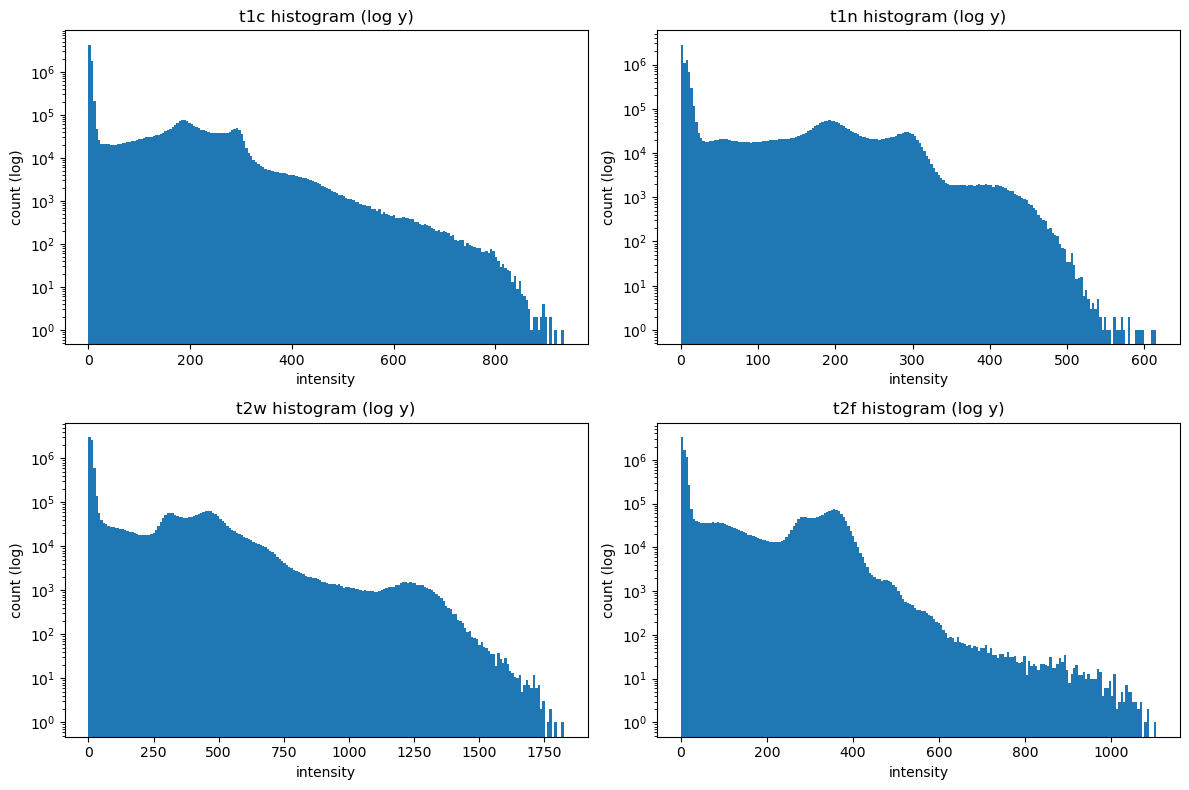

,modality,min,p1,p50,p99,max,mean,std
0,t1c,0.0,0.0,4.879796,391.934060,934.528931,60.570881,102.512954
1,t1n,0.0,0.0,7.327921,321.804232,615.516724,57.008052,94.026070
2,t2w,0.0,0.0,12.606592,792.769649,1824.776489,116.609097,203.652439
3,t2f,0.0,0.0,9.555124,399.641696,1105.110718,70.827524,123.909233


In [4]:
# ...existing code...
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

modalities = ["t1c", "t1n", "t2w", "t2f"]
subject = test_subjet

stats = []
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for i, m in enumerate(modalities):
    arr = subject[m].numpy().squeeze()
    vals = arr[np.isfinite(arr)].ravel()

    stats.append({
        "modality": m,
        "min": float(vals.min()),
        "p1": float(np.percentile(vals, 1)),
        "p50": float(np.percentile(vals, 50)),
        "p99": float(np.percentile(vals, 99)),
        "max": float(vals.max()),
        "mean": float(vals.mean()),
        "std": float(vals.std()),
    })

    axes[i].hist(vals, bins=200, log=True)
    axes[i].set_title(f"{m} histogram (log y)")
    axes[i].set_xlabel("intensity")
    axes[i].set_ylabel("count (log)")

plt.tight_layout()
plt.show()

display(pd.DataFrame(stats))
# ...existing code...

In [ ]:
import numpy as np
uniques = {}

all_unique_values = set()

for item in val_subjects:
    seg_data = item['seg'].numpy().squeeze()
    unique_vals = np.unique(seg_data)
    all_unique_values.update(unique_vals)

print("All unique values across validation set:", sorted(all_unique_values))

All unique values across validation set: [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4)]


In [2]:
import numpy as np

selected_labels = []

num_samples = 100
for i, batch in enumerate(train_loader):
    if i >= num_samples:
        break
    
    # Get patch size
    patch_size = batch['seg'][tio.DATA].shape[-1]
    center_idx = patch_size // 2
    
    # Get the label at center voxel
    label = int(batch['seg'][tio.DATA][0, 0, center_idx, center_idx, center_idx].item())
    selected_labels.append(label)

# Show distribution
unique, counts = np.unique(selected_labels, return_counts=True)
print("Label distribution from sampler:")
for label, count in zip(unique, counts):
    print(f"  Label {label}: {count} samples ({count/num_samples*100:.1f}%)")

Label distribution from sampler:
  Label 1: 22 samples (22.0%)
  Label 2: 65 samples (65.0%)
  Label 3: 9 samples (9.0%)
  Label 4: 4 samples (4.0%)


Transformed values:
t1c: min=0.0000, max=1.0000, mean=0.0648, std=0.1097
t1n: min=0.0000, max=1.0000, mean=0.0926, std=0.1528
t2w: min=0.0000, max=1.0000, mean=0.0639, std=0.1116
t2f: min=0.0000, max=1.0000, mean=0.0641, std=0.1121
